# Clustering (K-Means)

Este notebook explica o algoritmo K-Means e conceitos relacionados em detalhe, com exemplos práticos em Python.

Inclui:
- Definição e objetivo do clustering.
- Prós e contras do K-Means.
- Comparação entre aprendizagem supervisionada e não supervisionada.
- Explicação do método Elbow para escolher `K`.
- Implementação passo-a-passo de K-Means usando dados sintéticos (implementação "manual"), visualizações e métricas.

Sobre o exemplo prático (resumo):
- O exemplo gera dados sintéticos com `make_blobs` e mostra todo o fluxo do algoritmo K-Means implementado manualmente: inicialização de centróides, atribuição de pontos por distância, recomputação de centróides, iterações e visualização dos resultados. O objetivo é ajudar a entender cada etapa do algoritmo sem abstrações de alto nível.

## Índice
- O que é Clustering?
- O que faz o K-Means?
- Prós e Contras
- Tema 1: Aprendizagem Não Supervisionada vs Aprendizagem Supervisionada
- Tema 2: K-Means e Método Elbow (distância Euclidiana)
- Implementação — Preparação e exemplos práticos 
- Conclusões e referências

### O que é Clustering?
Clustering é um tipo de **aprendizagem não supervisionada** cujo objetivo é agrupar observações de forma que elementos no mesmo grupo (cluster) sejam mais semelhantes entre si do que com elementos de outros grupos. Não existem labels conhecidas: o algoritmo determina os grupos com base nas características dos dados.

### O que faz o K-Means?
O K-Means é um algoritmo de clustering que tenta particionar os dados em `K` clusters, minimizando a soma das distâncias quadradas entre cada ponto e o centro do seu cluster (inércia).

Passos do algoritmo (resumo prático):
1. Inicializar `K` centróides (aleatoriamente ou via k-means++).
2. Para cada ponto do conjunto de dados, calcular a distância (normalmente Euclidiana) entre o ponto e cada centróide.
3. Atribuir cada ponto ao cluster cujo centróide está mais próximo.
4. Recalcular cada centróide como a média dos pontos atribuídos ao seu cluster.
5. Repetir os passos 2–4 até convergência (centróides mudam pouco) ou atingir um número máximo de iterações.

Objetivo: minimizar a inércia (soma das distâncias quadradas intra-cluster). Em aplicações reais: escalar features, experimentar inicializações (`n_init`) e validar `K` com o método Elbow ou `silhouette_score`.

### Prós e Contras do K-Means
- **Prós:** rápido, fácil de implementar, funciona bem quando os clusters são aproximadamente esféricos e de tamanho similar.\n- **Contras:** é necessário escolher `K` a priori; sensível a inicialização e outliers; só encontra clusters convexos/esféricos; usa a média (não robusto a outliers).

## Tema 1: Aprendizagem Não Supervisionada vs Aprendizagem Supervisionada
### O que explicar: a ausência de labels e como o computador agrupa dados sozinho
- Na **aprendizagem supervisionada** temos pares $(X, y)$: cada exemplo tem uma etiqueta conhecida — por exemplo, prever se um cliente vai comprar ou não.
- Na **aprendizagem não supervisionada** (como clustering) **não** temos labels. O objetivo é explorar estrutura nos dados: o algoritmo agrupa pontos semelhantes com base nas suas características.

**Exemplo de uso:** segmentação de clientes — agrupar clientes por comportamento/valor para ações de marketing.

## Tema 2: O Algoritmo K-Means e o Método 'Elbow'
### Distância Euclidiana
O K-Means normalmente usa a distância Euclidiana para medir similaridade. A distância Euclidiana entre dois pontos $x=(x_1,\ldots,x_n)$ e $y=(y_1,\ldots,y_n)$ é:
$$
d(x,y) = \sqrt{\sum_{i=1}^n (x_i - y_i)^2},
$$
No objetivo do K-Means, minimizamos a soma das distâncias quadradas (inércia) entre pontos e o centróide do cluster.

### Método 'Elbow' para escolher `K`
O método Elbow consiste em treinar K-Means para vários valores de `K` e calcular a inércia (soma das distâncias quadradas). Normalmente plotamos inércia vs `K` e procuramos um ponto onde a melhoria (decréscimo da inércia) começa a diminuir — esse ponto é o 'cotovelo' (elbow) e sugere um `K` apropriado.

In [1]:
# Importar bibliotecas necessárias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler
from sklearn.datasets import make_blobs
%matplotlib inline
sns.set(style='whitegrid')

### K-Means passo-a-passo
Abaixo descrevemos, em detalhe, o que cada bloco de código faz no exemplo prático (o objetivo é que cada célula seja auto-explicativa):

1. Imports e configuração visual
   - Importamos `pandas`, `numpy`, `matplotlib`, `seaborn` e utilitários do `sklearn` para geração de dados e métricas. `sns.set` define o estilo dos gráficos.

2. Geração de dados sintéticos (`make_blobs`)
   - Criamos um conjunto de pontos `X` com `n_samples`, `n_features` e `centers` controlados, produzindo grupos naturais para testar o K-Means.
   - Visualizamos os pontos para ver a separação natural entre grupos.

3. Inicialização de centróides (aleatória)
   - Definimos `k = 3` e inicializamos um dicionário `clusters` onde cada entrada contém um `center` (vetor) e uma lista `points` vazia.
   - Isto simula a etapa de inicialização; no scikit-learn, `kmeans++` é uma opção mais robusta.
   - Seed faz com que a inicialização seja reprodutível.

4. Visualizar centróides iniciais
   - Plotamos os pontos e os centróides iniciais (marcados) para inspecionar a inicialização.

5. Função de distância
   - `distance(p1, p2)` calcula a distância Euclidiana entre dois vetores — usada para decidir a qual centróide cada ponto pertence.

6. Atribuição de pontos a clusters (`assign_clusters`)
   - Para cada ponto `x` em `X`, calculamos a distância a cada centróide e adicionamos `x` à lista `points` do cluster mais próximo.
   - Esta função apenas popula as listas `points` dos clusters; não altera centróides.

7. Atualização de centróides (`update_clusters`)
   - Para cada cluster, se existirem pontos atribuídos, calculamos a média desses pontos e definimos essa média como o novo centróide.
   - Após atualizar, limpamos a lista `points` para preparar a próxima iteração.

8. Previsão/rotulagem (`pred_cluster`)
   - Dada uma matriz `X`, retorna um vetor `pred` com o índice do cluster mais próximo para cada ponto (útil para plot e avaliação).

9. Loop de iterações (assign + update)
   - Executamos várias iterações do ciclo `assign_clusters` seguido de `update_clusters` até convergência ou número fixo de repetições.
   - No exemplo, isso é feito 5 vezes; em prática, verificar a mudança dos centróides ou usar um critério de paragem.

10. Visualizar resultados finais
   - Usamos `pred` para colorir os pontos conforme o cluster atribuído e plotamos os centróides finais (com marcador diferente).
   - Inspecionar o gráfico permite avaliar se os clusters fazem sentido e se o algoritmo convergiu para centróides estáveis.

11. Interpretação e próximos passos práticos
   - Sempre escalar features antes de usar K-Means (ex.: `StandardScaler`).
   - Testar diferentes valores de `K` (método Elbow) e calcular `silhouette_score` para complementar a análise.
   - Repetir o processo com varias inicializações (`n_init`) para evitar soluções locais.
   - Para dados com ruído ou clusters de forma arbitrária, considerar `DBSCAN` ou algoritmos hierárquicos.

Cada célula de código a seguir implementa exatamente uma destas etapas; leia a explicação anterior antes de executar para compreender o papel de cada célula.

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs

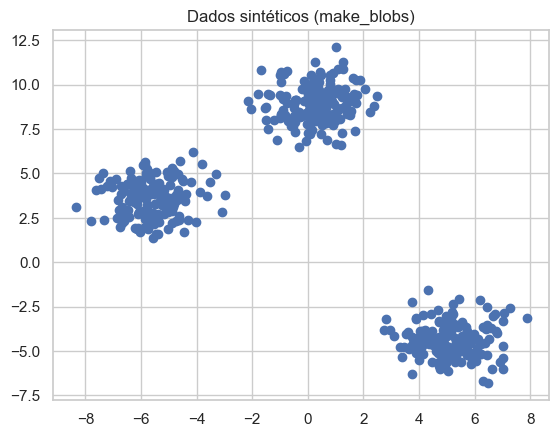

In [3]:
# Gerar dados sintéticos
X,y = make_blobs(n_samples = 500,n_features = 2,centers = 3,random_state = 23)

fig = plt.figure(0)
plt.grid(True)
plt.scatter(X[:,0],X[:,1])
plt.title('Dados sintéticos (make_blobs)')
plt.show()

In [12]:
k = 3

clusters = {}
np.random.seed(23)

for idx in range(k):
    center = 2*(2*np.random.random((X.shape[1],))-1)
    points = []
    cluster = {
        'center' : center,
        'points' : []
    }
    
    clusters[idx] = cluster
    
clusters

{0: {'center': array([0.06919154, 1.78785042]), 'points': []},
 1: {'center': array([ 1.06183904, -0.87041662]), 'points': []},
 2: {'center': array([-1.11581855,  0.74488834]), 'points': []}}

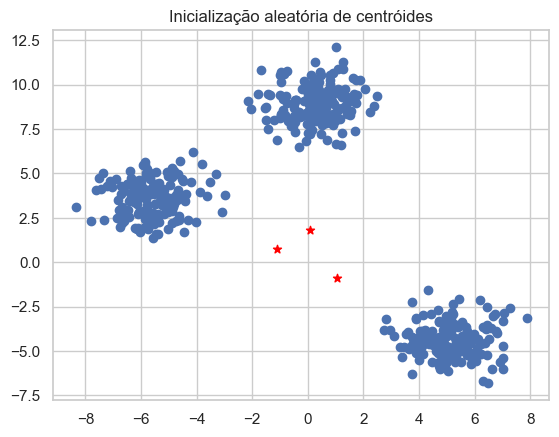

In [5]:
plt.scatter(X[:,0],X[:,1])
plt.grid(True)
for i in clusters:
    center = clusters[i]['center']
    plt.scatter(center[0],center[1],marker = '*',c = 'red')
plt.title('Inicialização aleatória de centróides')
plt.show()

In [6]:
def distance(p1,p2):
    return np.sqrt(np.sum((p1-p2)**2))

In [7]:
def assign_clusters(X, clusters):
    for idx in range(X.shape[0]):
        dist = []
        
        curr_x = X[idx]
        
        for i in range(k):
            dis = distance(curr_x,clusters[i]['center'])
            dist.append(dis)
        curr_cluster = np.argmin(dist)
        clusters[curr_cluster]['points'].append(curr_x)
    return clusters

def update_clusters(X, clusters):
    for i in range(k):
        points = np.array(clusters[i]['points'])
        if points.shape[0] > 0:
            new_center = points.mean(axis =0)
            clusters[i]['center'] = new_center
            
            clusters[i]['points'] = []
    return clusters

In [8]:
def pred_cluster(X, clusters):
    pred = []
    for i in range(X.shape[0]):
        dist = []
        for j in range(k):
            dist.append(distance(X[i],clusters[j]['center']))
        pred.append(np.argmin(dist))
    return pred

In [9]:
# Executar uma iteração completa de assign + update algumas vezes
for _ in range(5):
    clusters = assign_clusters(X,clusters)
    clusters = update_clusters(X,clusters)

pred = pred_cluster(X,clusters)


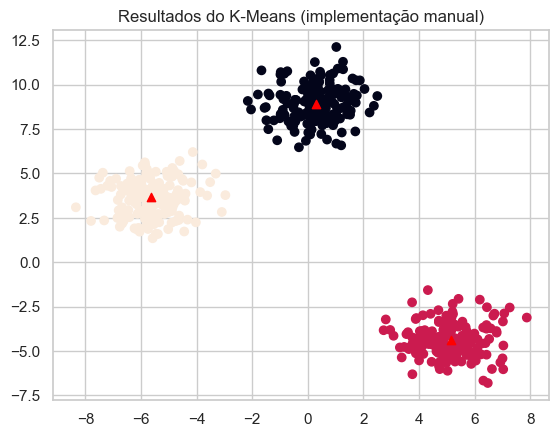

In [10]:
plt.scatter(X[:,0],X[:,1],c = pred)
for i in clusters:
    center = clusters[i]['center']
    plt.scatter(center[0],center[1],marker = '^',c = 'red')
plt.title('Resultados do K-Means (implementação manual)')
plt.show()

## Interpretação e boas práticas
Escalar features antes de aplicar K-Means (StandardScaler) é normalmente essencial porque o algoritmo usa distâncias.

Experimentar várias inicializações (`n_init`) e usar `random_state` para reprodutibilidade.

O método Elbow é heurístico; pode complementar com `silhouette_score` ou validação através de conhecimento do domínio.

Lidar com outliers antes: outliers podem deslocar centróides.

## Conclusões e referências
- O K-Means é uma ferramenta simples e eficaz para encontrar clusters quando os grupos são aproximadamente esféricos e de dimensão moderada.

Referência de leitura (exemplo usado como guia): https://www.geeksforgeeks.org/machine-learning/k-means-clustering-introduction/